# Imports

In [ ]:
import numpy as np 
import h5py
import warnings

from egb_jax_eccentric import (
    EccentricBinaryParams,
    aet_from_xyz,
    eccentric_complex_strain,
    eccentric_links_jax,
    eccentric_xyz_jax,
    lisa_orbit,
    precompute_jax_link_geometry,
    default_lisaorbits, 
    state_from_lisaorbits
)
from egb_jax_eccentric.constants import PARSEC_M, KILOPARSEC_M
from astropy.coordinates import SkyCoord, BarycentricTrueEcliptic
import astropy.units as u
import json



In [ ]:
import os
work_dir='/home/svu/e1498138/localgit/eGB-multi'
scratch_dir='/scratch/e1498138/eGB-multi'
os.chdir(work_dir)

sangria_path = scratch_dir + '/data/LDC2_sangria_training_v2.h5'
output_path = scratch_dir + '/data/sangria_hmcnc.h5'

# Read Sangria Data

In [16]:
XYZ = ("X", "Y", "Z")
AET = ("A", "E", "T")

In [ ]:
## Functions to read sangria data (from notebook)

def scalar(h5: h5py.File, key: str):
    value = h5[key][()]
    return value.decode() if isinstance(value, bytes) else np.asarray(value).item()


def read_tdi_group(h5: h5py.File, path: str, start: int, stop: int) -> dict[str, np.ndarray]:
    block = h5[path][start:stop, 0]
    return {name: np.asarray(block[name], dtype=np.float64) for name in ("t", *XYZ)}


def segment_bounds(h5: h5py.File, start_s: float, duration_days: float) -> tuple[int, int, float, float]:
    dset = h5["obs/tdi"]
    dt, t0 = float(dset.attrs["dt"]), float(dset.attrs["t0"])
    start = int(round((start_s - t0) / dt))
    stop = min(start + int(round(duration_days * 86400.0 / dt)), dset.shape[0])
    if stop <= start:
        raise ValueError("empty segment requested")
    return start, stop, dt, t0



In [ ]:
sky_paths = ["sky/dgb/tdi", "sky/igb/tdi", "sky/vgb/tdi", "sky/mbhb/tdi"]

segment_start_s = 0.0
segment_duration_days = 1.0

with h5py.File(sangria_path, "r") as h5:
    start, stop, dt, t0 = segment_bounds(h5, segment_start_s, segment_duration_days)

    obs_xyz = read_tdi_group(h5, "obs/tdi", start, stop)
    source_components = {path: read_tdi_group(h5, path, start, stop) for path in sky_paths}
    noise_xyz = {
        "t": obs_xyz["t"],
        **{ch: obs_xyz[ch] - sum(comp[ch] for comp in source_components.values()) for ch in XYZ},
    }

    sangria_metadata = {
        "obs_tdi_dt_s": dt,
        "obs_tdi_t0_s": t0,
        "obs_tdi_units": str(h5["obs/tdi"].attrs.get("units", "")),
        "obs_orbit_type": scalar(h5, "obs/config/orbit_type") if "obs/config/orbit_type" in h5 else "unknown",
        "nominal_arm_length_m": scalar(h5, "obs/config/nominal_arm_length") if "obs/config/nominal_arm_length" in h5 else None,
        "tdi_generation": scalar(h5, "instru/config/TDI_GENERATION") if "instru/config/TDI_GENERATION" in h5 else None,
        "tdi_input_format": scalar(h5, "instru/config/TDI_INPUT_FORMAT") if "instru/config/TDI_INPUT_FORMAT" in h5 else None,
    }

print("segment samples:", stop - start)
print("segment start/stop seconds:", noise_xyz["t"][0], noise_xyz["t"][-1])
print("Sangria metadata:", json.dumps(sangria_metadata, indent=2, default=float))
print("noise max abs:", {channel: float(np.max(np.abs(noise_xyz[channel]))) for channel in XYZ})


segment samples: 17280
segment start/stop seconds: 0.0 86395.0
Sangria metadata: {
  "obs_tdi_dt_s": 5.0,
  "obs_tdi_t0_s": 0.0,
  "obs_tdi_units": "dimensionless",
  "obs_orbit_type": "equal_armlength",
  "nominal_arm_length_m": 2500000000.0,
  "tdi_generation": 1.5,
  "tdi_input_format": "hdf5"
}
noise max abs: {'X': 4.483154192617309e-20, 'Y': 3.822953706522113e-20, 'Z': 3.678334186058848e-20}


# Inject source 

In [ ]:
# HM Cnc
period_s = 321.529129
pdot = -3.75e-11   
ra_deg=121.5957
dec_deg =15.4586
m1_sol=0.55
m2_sol=0.27
dist_pc = 7500.0  #pc
inc_deg = 38.0#deg
ecc=0.1 # its actually circular but we'll just try ok 

In [ ]:

coord = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
ecl = coord.transform_to(BarycentricTrueEcliptic())

source_params = {
    "f0_hz": 2.0 / period_s,  
    "eccentricity": ecc,   
    "m1_solar": m1_sol,
    "m2_solar": m2_sol,
    "distance_m": dist_pc * PARSEC_M,  
    "beta": float(ecl.lat.rad),
    "lambda_": float(ecl.lon.rad),
    "psi": 0.0,
    "inclination": np.radians(inc_deg),
    "phi0": 0.0,
    "fdot": 0.0,
}

injection_scale = 1.0 # scale up if not visible

print("input:", sangria_path)
print("output:", output_path)
print("source:", json.dumps(source_params, indent=2, default=float))

input: /scratch/e1498138/eGB-multi/data/LDC2_sangria_training_v2.h5
output: /scratch/e1498138/eGB-multi/data/sangria_hmcnc.h5
source: {
  "f0_hz": 0.00622027623506547,
  "eccentricity": 0.1,
  "m1_solar": 0.55,
  "m2_solar": 0.27,
  "distance_m": 2.3142581861185254e+20,
  "beta": -0.08210049881437637,
  "lambda_": 2.102052384246663,
  "psi": 0.0,
  "inclination": 0.6632251157578453,
  "phi0": 0.0,
  "fdot": 0.0
}


In [ ]:
sangria_tdi_generation = sangria_metadata["tdi_generation"]

# NOTE: SANGRIA IS GEN1.5!!
# we'll use pytdi gen 1 (downgrade : ( ))
# consider pytdi gen 2 since it covers rotation as well? 

egb_pytdi_gen = 1
measurement_order = 3
delay_order = 3

In [ ]:
t = noise_xyz["t"]
state = state_from_lisaorbits(default_lisaorbits("equal"), t)
source = EccentricBinaryParams(
    mean_motion=np.pi * source_params["f0_hz"],
    eccentricity=source_params["eccentricity"],
    m1_solar=source_params["m1_solar"],
    m2_solar=source_params["m2_solar"],
    distance_m=source_params["distance_m"],
    beta=source_params["beta"],
    lambda_=source_params["lambda_"],
    psi=source_params["psi"],
    inclination=source_params["inclination"],
    phi0=source_params["phi0"],
    fdot=source_params["fdot"],
)

raw_signal_xyz = eccentric_xyz_jax(
    state,
    source,
    batch_size=1,
    physics_mode="1pn_periastron", #NOTE: 1pn
    generation=egb_pytdi_gen,
    measurement_order=measurement_order,
    delay_order=delay_order,
)

/scratch/e1498138/anaconda3/envs/egb-multi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/scratch/e1498138/anaconda3/envs/egb-multi/lib/python3.11/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.2.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.1
  warnings.warn(
/scratch/e1498138/anaconda3/envs/egb-multi/lib/python3.11/site-packages/pytdi/dsp.py:72: ComplexWarning: Casting complex values to real discards the imaginary part
  return data.astype(float)


In [ ]:
# The local response is an analytic complex representation. Sangria stores real dimensionless TDI series.
signal_xyz = {channel: np.real(np.asarray(raw_signal_xyz[channel], dtype=np.complex128)).astype(np.float64) for channel in XYZ}
imaginary_fraction = {}
for channel in XYZ:
    arr = np.asarray(raw_signal_xyz[channel], dtype=np.complex128)
    denom = max(float(np.max(np.abs(np.real(arr)))), np.finfo(float).tiny)
    imaginary_fraction[channel] = float(np.max(np.abs(np.imag(arr))) / denom)

injected_xyz = {"t": t.copy(), **{channel: noise_xyz[channel] + injection_scale * signal_xyz[channel] for channel in XYZ}}

print("signal max abs:", {channel: float(np.max(np.abs(signal_xyz[channel]))) for channel in XYZ})
print("analytic-signal imaginary/real max fractions:", imaginary_fraction)

signal max abs: {'X': 1.696574449237748e-23, 'Y': 1.6276603222081335e-23, 'Z': 2.1934226890644953e-23}
analytic-signal imaginary/real max fractions: {'X': 0.0, 'Y': 0.0, 'Z': 0.0}


# Write inj file

In [ ]:
os.makedirs(os.path.dirname(output_path), exist_ok=True)

with h5py.File(output_path, "w") as out:
    out.attrs["source_record"] = "Zenodo 10.5281/zenodo.7132178, LISA Data Challenge Sangria (LDC2a)"
    out.attrs["input_hdf5"] = str(sangria_path)
    out.attrs["segment_start_s"] = float(t[0])
    out.attrs["segment_stop_s"] = float(t[-1])
    out.attrs["segment_dt_s"] = float(dt)
    out.attrs["noise_definition"] = "obs/tdi minus sky/dgb, sky/igb, sky/vgb, and sky/mbhb TDI components from the same Sangria training file"
    out.attrs["sangria_metadata_json"] = json.dumps(sangria_metadata, default=float)
    out.attrs["egb_source_params_json"] = json.dumps(source_params, default=float)
    # out.attrs["egb_signal_backend"] = signal_backend
    out.attrs["egb_pytdi_generation"] = 2.0
    out.attrs["injection_scale"] = 1.0
    out.attrs["convention_status"] = "approximate demonstration: Sangria stores TDI_GENERATION=1.5 while this egb_jax_eccentric signal uses pyTDI generation 2"

    out.create_dataset("t", data=t, compression="gzip")
    for group_name, series in (("noise", noise_xyz), ("eccentric_signal", signal_xyz), ("injected", injected_xyz)):
        group = out.create_group(group_name)
        for channel in XYZ:
            group.create_dataset(channel, data=series[channel], compression="gzip")

print("wrote", output_path)
with h5py.File(output_path, "r") as check:
    print("groups:", list(check.keys()))
    print("samples:", check["t"].shape[0])
    print("max |injected - noise|:", {channel: float(np.max(np.abs(check["injected"][channel][:] - check["noise"][channel][:]))) for channel in XYZ})



wrote /scratch/e1498138/eGB-multi/data/sangria_hmcnc.h5
groups: ['eccentric_signal', 'injected', 'noise', 't']
samples: 17280
max |injected - noise|: {'X': 1.696574449237756e-23, 'Y': 1.6276603222080976e-23, 'Z': 2.1934226890645255e-23}


# Figures

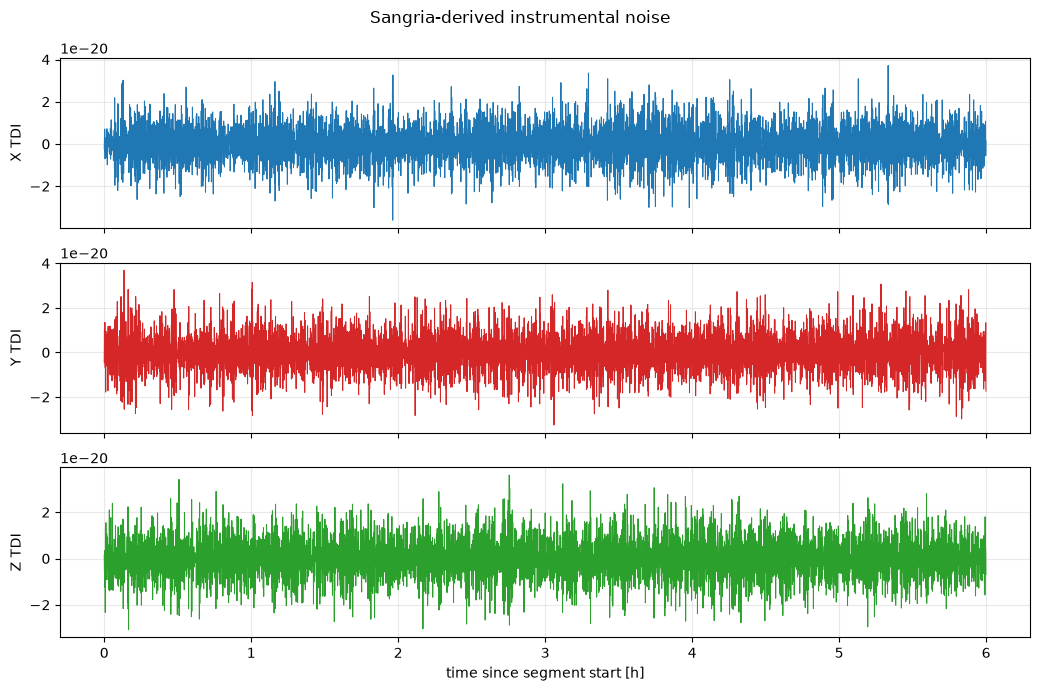

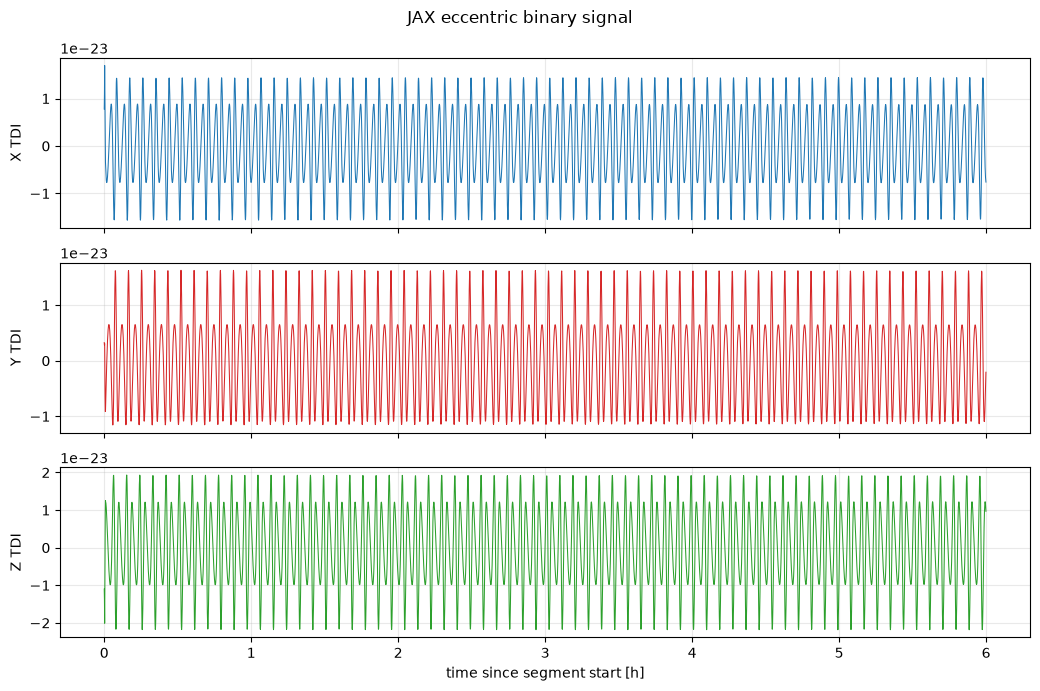

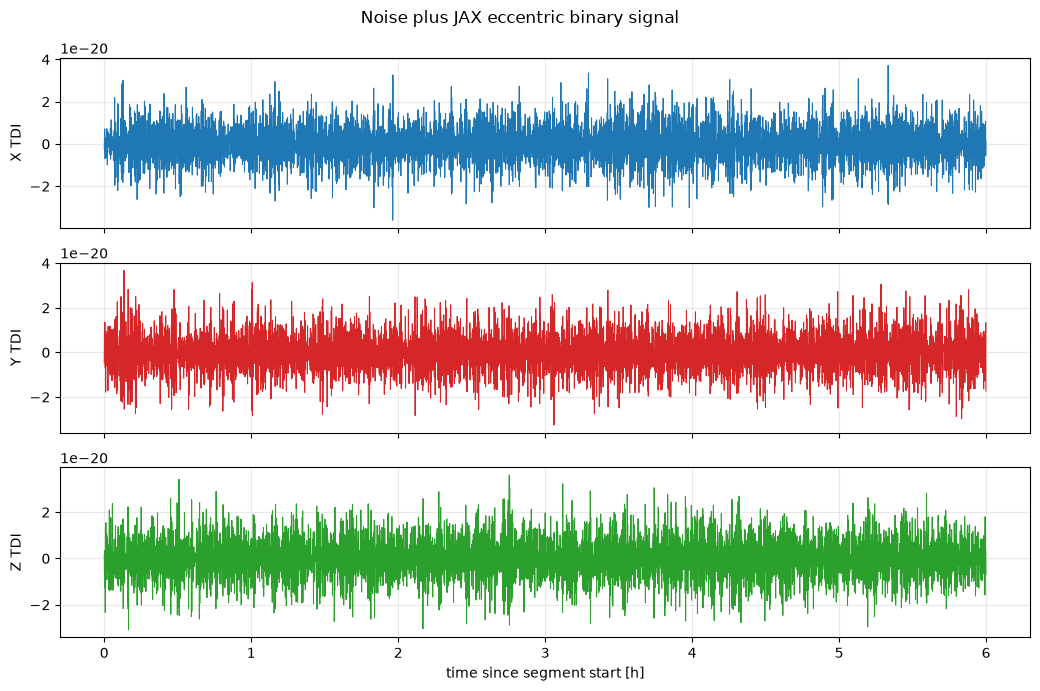

In [ ]:
import matplotlib.pyplot as plt

plot_labels = {
    "noise": "Sangria-derived instrumental noise",
    "eccentric_signal": "JAX eccentric binary signal",
    "injected": "Noise plus JAX eccentric binary signal",
}
plot_colors = {"X": "#1f77b4", "Y": "#d62728", "Z": "#2ca02c"}
plot_count = min(t.size, int(6 * 3600 / dt))
tt_hours = (t[:plot_count] - t[0]) / 3600.0
series_by_group = {"noise": noise_xyz, "eccentric_signal": signal_xyz, "injected": injected_xyz}

for group_name, series in series_by_group.items():
    fig, axes = plt.subplots(3, 1, figsize=(10.5, 7.0), sharex=True)
    for ax, channel in zip(axes, XYZ):
        y = series[channel][:plot_count]
        ax.plot(tt_hours, y, lw=0.75, color=plot_colors[channel])
        ax.set_ylabel(f"{channel} TDI")
        ax.grid(alpha=0.28)
    axes[-1].set_xlabel("time since segment start [h]")
    fig.suptitle(plot_labels[group_name])
    fig.tight_layout()
    plt.show()